In [8]:
!pip install xgboost
!pip install lightgbm
!pip install shap

## 1. Imports & Setup

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import shap

sns.set_style('whitegrid')
print('All libraries loaded successfully!')

All libraries loaded successfully!


## 2. Load Data

In [12]:
df = pd.read_csv(r"C:\Users\ENVY\OneDrive\Desktop\FOLDERS\python\fraud detection\banking_transactions.csv")
df['fraud_flag'] = df['fraud_flag'].astype(int)

print(f'Dataset Shape: {df.shape}')
print(f'Fraud Rate: {df["fraud_flag"].mean()*100:.2f}%')
print(f'\nFraud Distribution:')
print(df['fraud_flag'].value_counts())

Dataset Shape: (10000, 20)
Fraud Rate: 12.51%

Fraud Distribution:
fraud_flag
0    8749
1    1251
Name: count, dtype: int64


## 3. Feature Engineering

In [13]:
# Feature 1: High-risk combination (suspicious IP + international transaction)
df['high_risk_combo'] = (
    (df['suspicious_ip_flag'] == 1) & (df['international_transaction_flag'] == 1)
).astype(int)

# Feature 2: Late night transaction flag (12 AM - 4 AM)
df['late_night_flag'] = df['transaction_time_hour'].apply(
    lambda x: 1 if x in [0, 1, 2, 3, 4] else 0
)

# Feature 3: Transaction-to-balance ratio (spending relative to avg balance)
df['balance_to_txn_ratio'] = df['transaction_amount'] / (df['avg_monthly_balance'] + 1)

# Feature 4: Anomaly-velocity interaction (combined risk signal)
df['anomaly_velocity_interaction'] = df['anomaly_score'] * df['transaction_velocity_score']

# Feature 5: High anomaly flag (top 25% anomaly scores)
df['high_anomaly_flag'] = (
    df['anomaly_score'] > df['anomaly_score'].quantile(0.75)
).astype(int)

print('New features created:')
new_feats = ['high_risk_combo','late_night_flag','balance_to_txn_ratio',
             'anomaly_velocity_interaction','high_anomaly_flag']
print(df[new_feats].describe())

New features created:
       high_risk_combo  late_night_flag  balance_to_txn_ratio  \
count     10000.000000     10000.000000          10000.000000   
mean          0.247100         0.209300              0.199351   
std           0.431347         0.406829              1.828728   
min           0.000000         0.000000              0.000030   
25%           0.000000         0.000000              0.024833   
50%           0.000000         0.000000              0.049460   
75%           0.000000         0.000000              0.101413   
max           1.000000         1.000000            146.292221   

       anomaly_velocity_interaction  high_anomaly_flag  
count                  10000.000000       10000.000000  
mean                      17.538682           0.244700  
std                       17.289233           0.429931  
min                        0.000000           0.000000  
25%                        4.223750           0.000000  
50%                       12.762500           0.00

## 4. Preprocessing

### 4.1 One-Hot Encode Categorical Columns

In [14]:
df_model = pd.get_dummies(df, columns=['payment_channel', 'authentication_type'], drop_first=False)

X = df_model.drop(columns=['transaction_id', 'fraud_flag'])
y = df_model['fraud_flag']

print(f'Features shape: {X.shape}')
print(f'Feature list: {list(X.columns)}')

Features shape: (10000, 29)
Feature list: ['transaction_amount', 'login_attempts', 'device_risk_score', 'transfer_frequency', 'anomaly_score', 'account_age_days', 'transaction_time_hour', 'failed_transactions_last_30d', 'avg_monthly_balance', 'daily_transaction_count', 'geo_distance_km', 'session_duration_minutes', 'transaction_velocity_score', 'card_present_flag', 'international_transaction_flag', 'suspicious_ip_flag', 'high_risk_combo', 'late_night_flag', 'balance_to_txn_ratio', 'anomaly_velocity_interaction', 'high_anomaly_flag', 'payment_channel_ATM', 'payment_channel_Mobile App', 'payment_channel_POS Terminal', 'payment_channel_Web Banking', 'authentication_type_Biometric', 'authentication_type_OTP', 'authentication_type_Password Only', 'authentication_type_Two-Factor Authentication']


### 4.2 Train-Test Split (Stratified)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Train fraud %: {y_train.mean()*100:.2f}% | Test fraud %: {y_test.mean()*100:.2f}%')

Train size: 8000 | Test size: 2000
Train fraud %: 12.51% | Test fraud %: 12.50%


### 4.3 Standard Scaling

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('Scaling complete.')

Scaling complete.


### 4.4 Handle Class Imbalance with SMOTE


In [17]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print('Before SMOTE:', dict(pd.Series(y_train).value_counts()))
print('After SMOTE: ', dict(pd.Series(y_train_res).value_counts()))

Before SMOTE: {0: 6999, 1: 1001}
After SMOTE:  {0: 6999, 1: 6999}


## 5. Model Training & Evaluation

We train 4 models and compare them on Precision, Recall, F1, and AUC-ROC.

> **Key metric: Recall** — In fraud detection, missing a real fraud (false negative) is more costly than a false alarm.

In [24]:
results = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred  = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    auc   = roc_auc_score(y_te, proba)
    f1    = f1_score(y_te, pred)
    prec  = precision_score(y_te, pred)
    rec   = recall_score(y_te, pred)
    results[name] = {'Precision': round(prec,4), 'Recall': round(rec,4),
                     'F1-Score': round(f1,4), 'AUC-ROC': round(auc,4)}
    print(f'\n=== {name} ===')
    print(classification_report(y_te, pred, target_names=['Non-Fraud','Fraud']))
    print(f'AUC-ROC: {auc:.4f}')
    return model, pred, proba

### 5.1 Logistic Regression (Baseline)

In [25]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr, lr_pred, lr_proba = evaluate_model('Logistic Regression', lr,
                                        X_train_res, y_train_res, X_test_scaled, y_test)


=== Logistic Regression ===
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.93      0.96      1750
       Fraud       0.66      0.92      0.77       250

    accuracy                           0.93      2000
   macro avg       0.82      0.93      0.86      2000
weighted avg       0.95      0.93      0.94      2000

AUC-ROC: 0.9782


### 5.2 Random Forest

In [26]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf, rf_pred, rf_proba = evaluate_model('Random Forest', rf,
                                        X_train_res, y_train_res, X_test_scaled, y_test)


=== Random Forest ===
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.93      0.96      1750
       Fraud       0.67      0.93      0.78       250

    accuracy                           0.93      2000
   macro avg       0.83      0.93      0.87      2000
weighted avg       0.95      0.93      0.94      2000

AUC-ROC: 0.9743


### 5.3 XGBoost

In [27]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='logloss', verbosity=0
)
xgb_model, xgb_pred, xgb_proba = evaluate_model('XGBoost', xgb_model,
                                                   X_train_res, y_train_res, X_test_scaled, y_test)


=== XGBoost ===
              precision    recall  f1-score   support

   Non-Fraud       0.98      0.95      0.97      1750
       Fraud       0.72      0.89      0.80       250

    accuracy                           0.94      2000
   macro avg       0.85      0.92      0.88      2000
weighted avg       0.95      0.94      0.95      2000

AUC-ROC: 0.9770


### 5.4 LightGBM

In [28]:
lgbm = lgb.LGBMClassifier(
    n_estimators=200, learning_rate=0.05,
    num_leaves=31, random_state=42, verbosity=-1
)
lgbm, lgbm_pred, lgbm_proba = evaluate_model('LightGBM', lgbm,
                                               X_train_res, y_train_res, X_test_scaled, y_test)


=== LightGBM ===
              precision    recall  f1-score   support

   Non-Fraud       0.98      0.97      0.97      1750
       Fraud       0.78      0.84      0.81       250

    accuracy                           0.95      2000
   macro avg       0.88      0.91      0.89      2000
weighted avg       0.95      0.95      0.95      2000

AUC-ROC: 0.9769


## 6. Model Comparison Table

                     Precision  Recall  F1-Score  AUC-ROC
Logistic Regression     0.6581   0.924    0.7687   0.9782
XGBoost                 0.7231   0.888    0.7971   0.9770
LightGBM                0.7844   0.844    0.8131   0.9769
Random Forest           0.6715   0.932    0.7806   0.9743


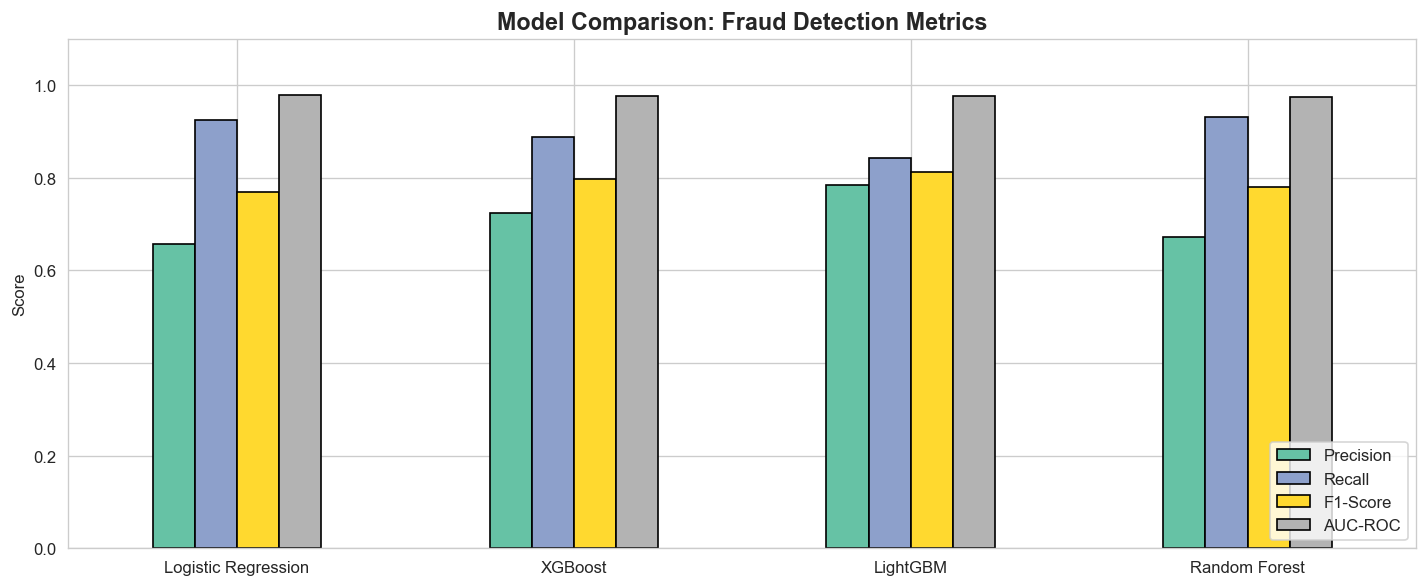

In [29]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('AUC-ROC', ascending=False)
print(results_df.to_string())

# Visual bar chart comparison
results_df.plot(kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='black')
plt.title('Model Comparison: Fraud Detection Metrics', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 7. Confusion Matrices (All Models)

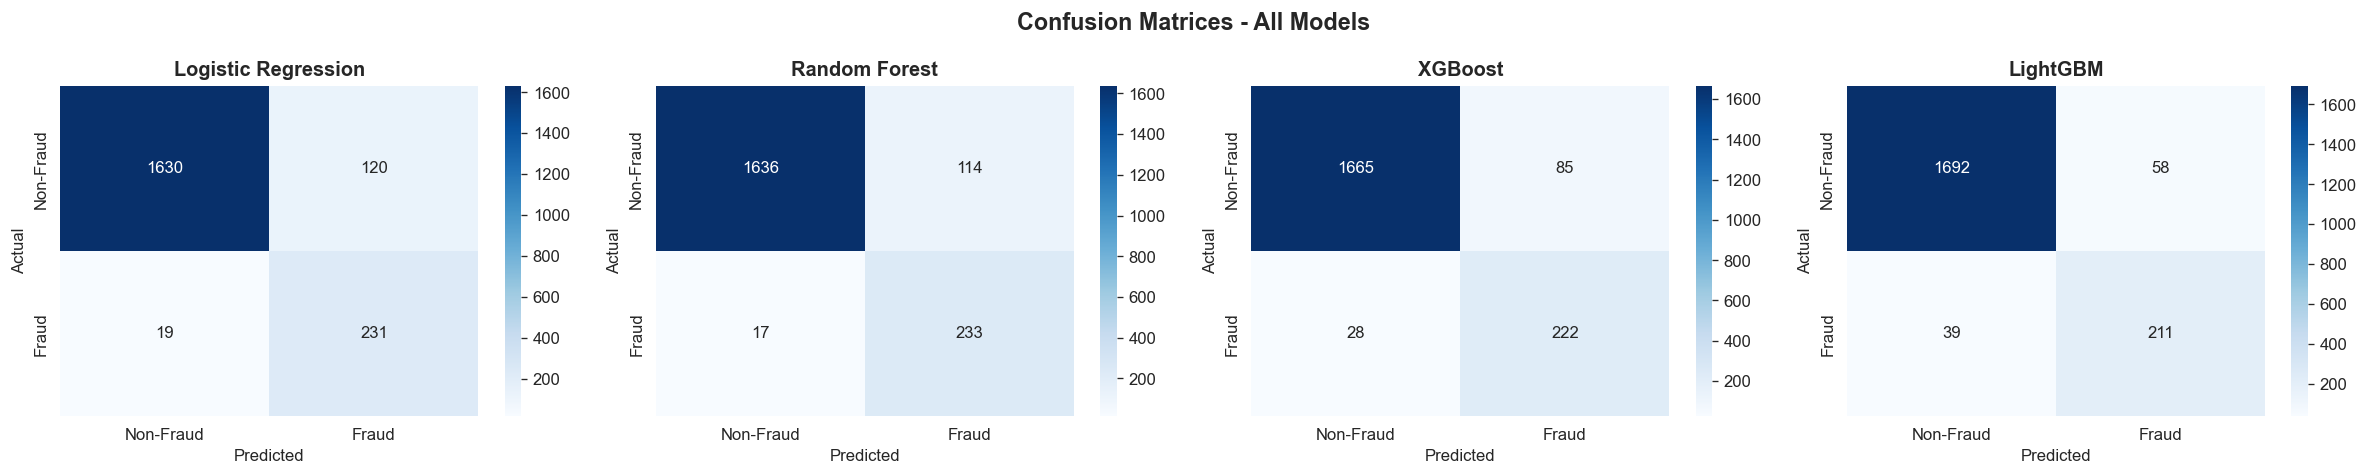

In [30]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
models_preds = [
    ('Logistic Regression', lr_pred),
    ('Random Forest',       rf_pred),
    ('XGBoost',            xgb_pred),
    ('LightGBM',           lgbm_pred),
]
for ax, (name, pred) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Fraud','Fraud'],
                yticklabels=['Non-Fraud','Fraud'])
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices - All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. ROC Curves (All Models)

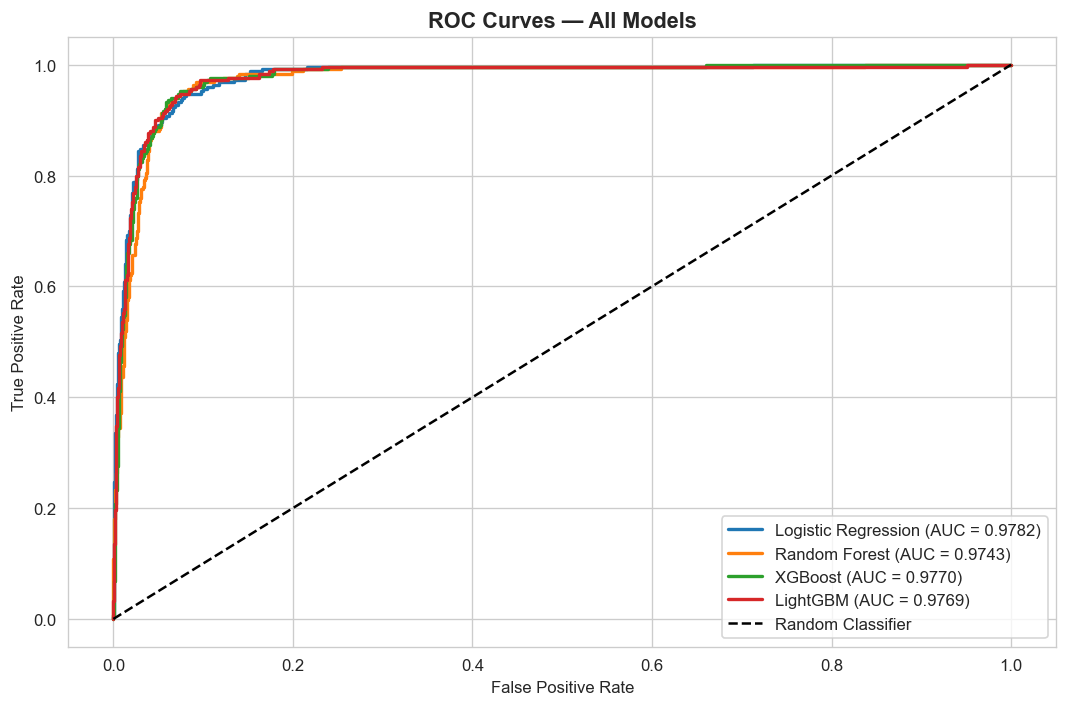

In [31]:
plt.figure(figsize=(9, 6))
models_probas = [
    ('Logistic Regression', lr_proba),
    ('Random Forest',       rf_proba),
    ('XGBoost',            xgb_proba),
    ('LightGBM',           lgbm_proba),
]
for name, proba in models_probas:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', linewidth=2)

plt.plot([0,1],[0,1],'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Feature Importance — XGBoost

XGBoost and LightGBM give the most reliable feature importances.

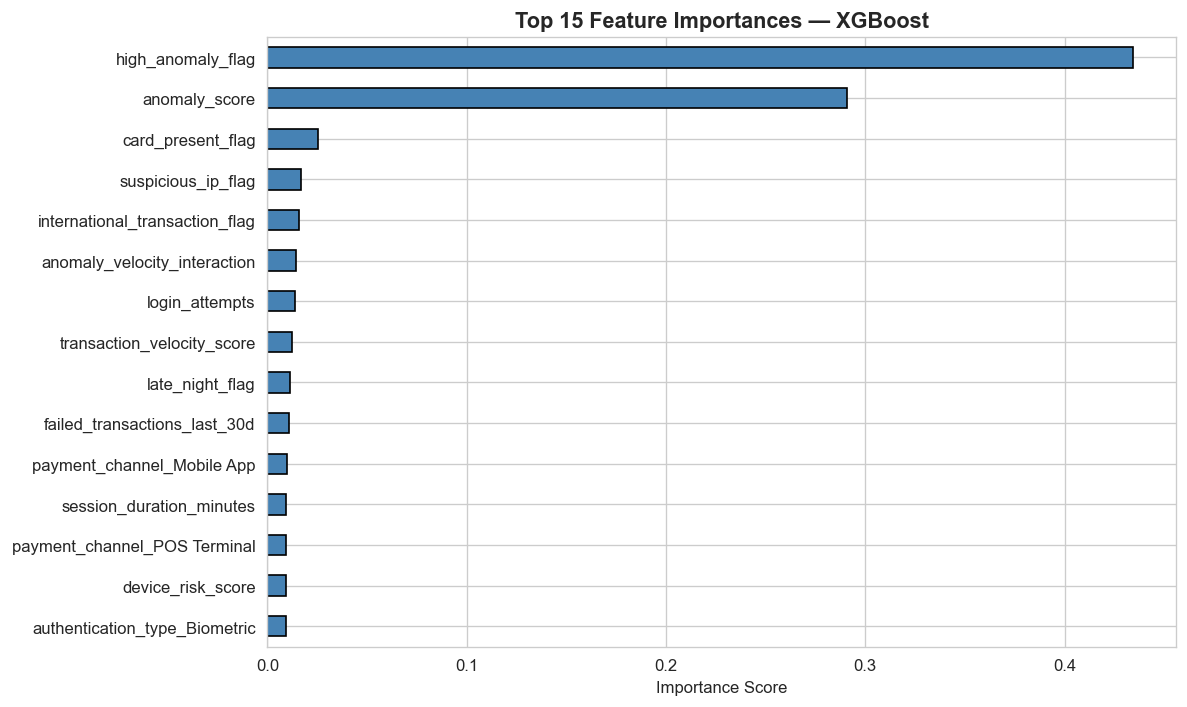

high_anomaly_flag                 0.434207
anomaly_score                     0.290713
card_present_flag                 0.025612
suspicious_ip_flag                0.017094
international_transaction_flag    0.015963
anomaly_velocity_interaction      0.014264
login_attempts                    0.013830
transaction_velocity_score        0.012518
late_night_flag                   0.011431
failed_transactions_last_30d      0.010837
payment_channel_Mobile App        0.009715
session_duration_minutes          0.009273
payment_channel_POS Terminal      0.009249
device_risk_score                 0.009180
authentication_type_Biometric     0.009141
dtype: float32


In [32]:
feat_imp = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
feat_imp.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 15 Feature Importances — XGBoost', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()
print(feat_imp)

## 10. SHAP Explainability

SHAP (SHapley Additive exPlanations) explains WHY the model made each prediction. This is critical for trust and interpretability.

PermutationExplainer explainer: 501it [00:28, 15.55it/s]                                                               


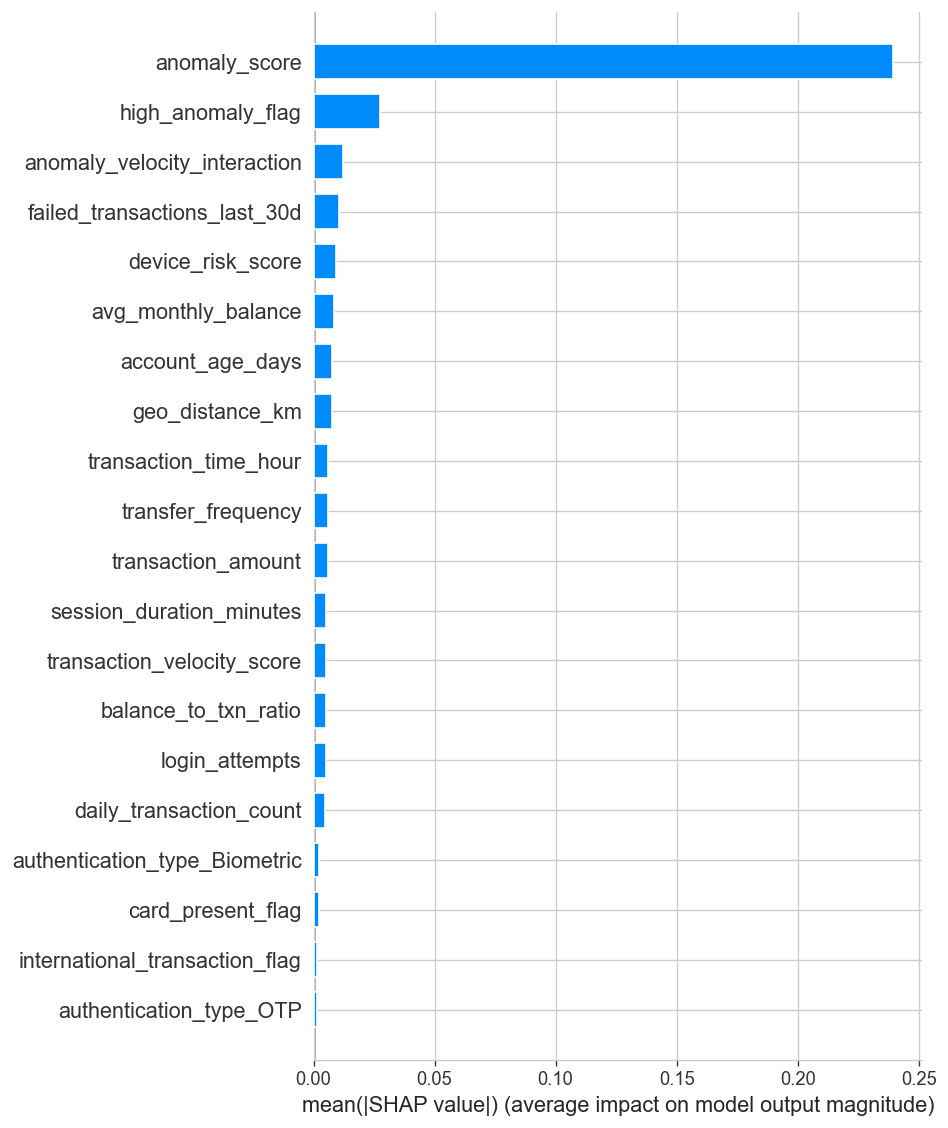

In [36]:
explainer = shap.Explainer(
    xgb_model.predict,
    X_test_scaled[:100]
)

shap_values = explainer(X_test_scaled[:500])

# Summary plot: shows which features matter most and in which direction
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_scaled[:500],
    feature_names=list(X.columns),
    plot_type='bar'
)

PermutationExplainer explainer: 501it [00:21, 12.54it/s]                                                               


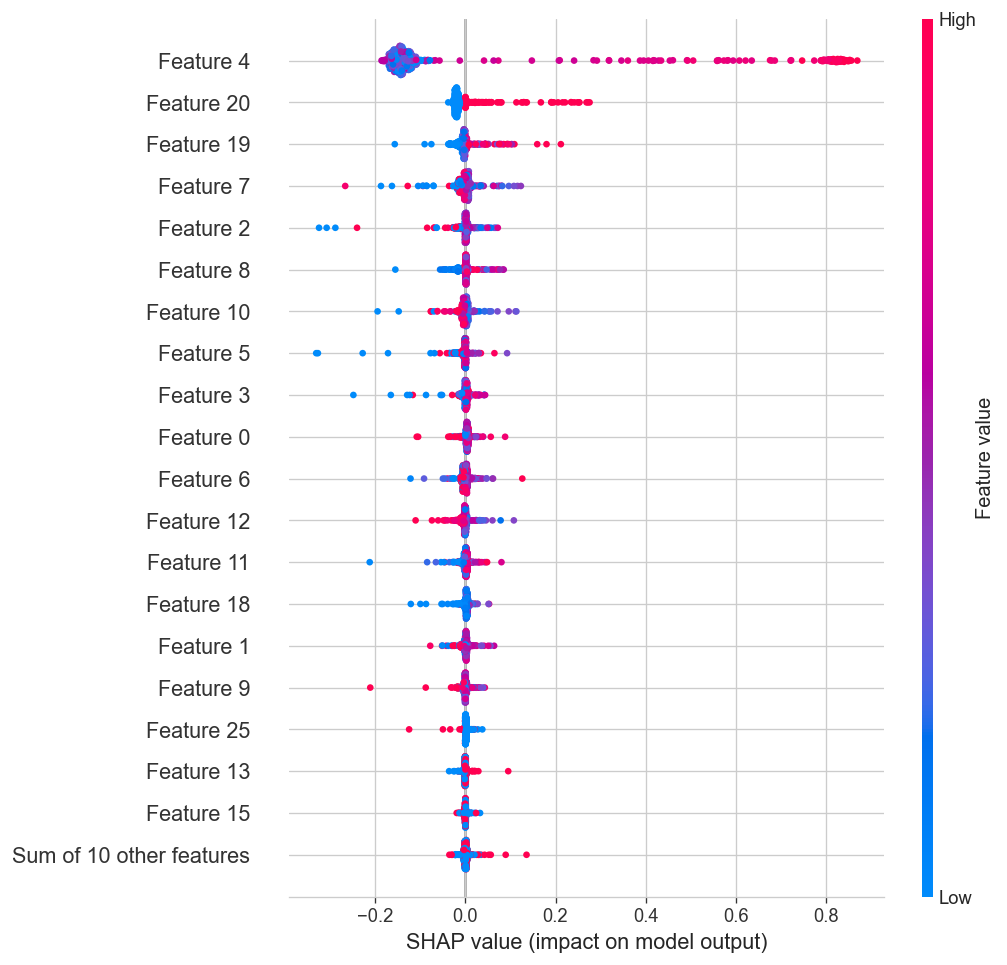

In [39]:
# Beeswarm plot
shap_vals = explainer(X_test_scaled[:500])
shap.plots.beeswarm(shap_vals, max_display=20)
plt.show()

Explaining prediction for test sample index 11 (Actual: Fraud, Predicted: Fraud)


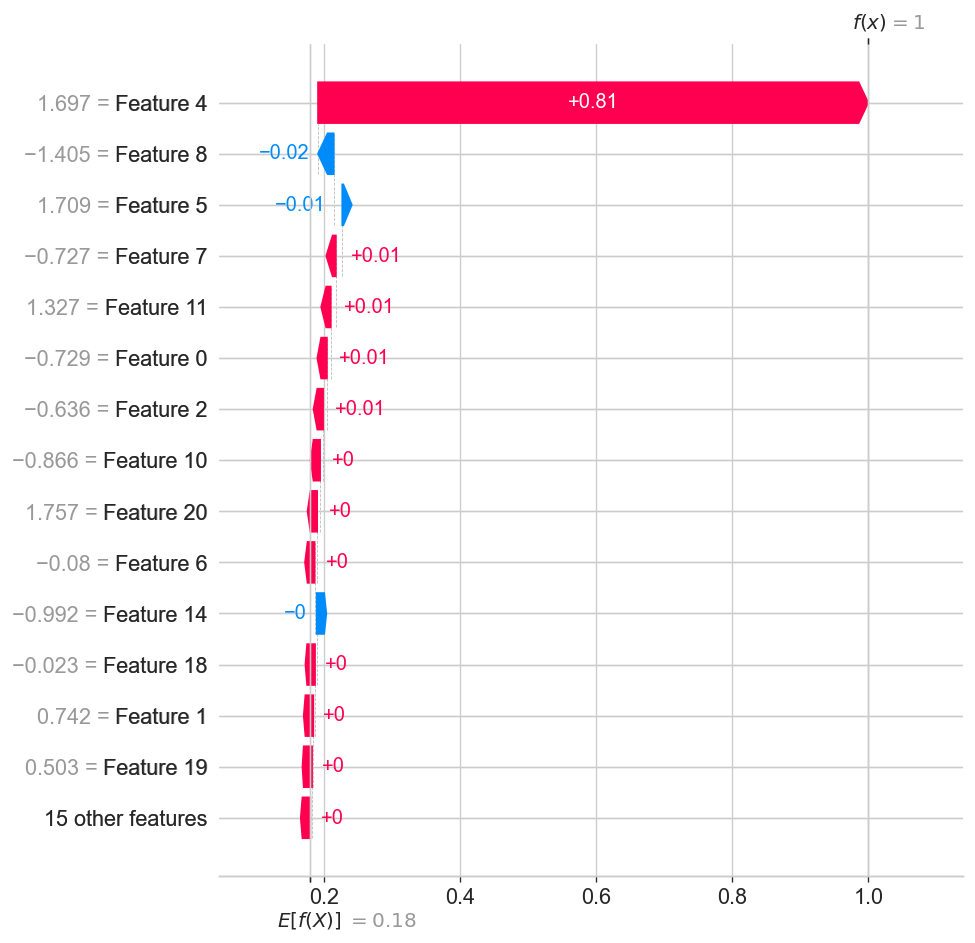

In [40]:
# Find a correctly predicted fraud transaction
fraud_indices = [
    i for i, p in enumerate(xgb_pred)
    if p == 1 and y_test.iloc[i] == 1
]

idx = fraud_indices[0]

print(
    f'Explaining prediction for test sample index {idx} '
    f'(Actual: Fraud, Predicted: Fraud)'
)

# Waterfall plot
shap.plots.waterfall(shap_vals[idx], max_display=15)

## 11. Export Predictions for Power BI

In [ ]:
# # Add predictions and probability scores back to original dataframe
# df_original = pd.read_csv('banking_transactions.csv')
# df_original['fraud_flag'] = df_original['fraud_flag'].astype(int)

# # Feature engineering
# df_original['high_risk_combo'] = ((df_original['suspicious_ip_flag'] == 1) & (df_original['international_transaction_flag'] == 1)).astype(int)
# df_original['late_night_flag'] = df_original['transaction_time_hour'].apply(lambda x: 1 if x in [0,1,2,3,4] else 0)
# df_original['balance_to_txn_ratio'] = df_original['transaction_amount'] / (df_original['avg_monthly_balance'] + 1)
# df_original['anomaly_velocity_interaction'] = df_original['anomaly_score'] * df_original['transaction_velocity_score']
# df_original['high_anomaly_flag'] = (df_original['anomaly_score'] > df_original['anomaly_score'].quantile(0.75)).astype(int)

# # Risk category for dashboard
# def risk_category(score):
#     if score >= 0.75: return 'Critical'
#     elif score >= 0.5: return 'High'
#     elif score >= 0.25: return 'Medium'
#     else: return 'Low'

# df_original['risk_category'] = df_original['anomaly_score'].apply(risk_category)

# def time_of_day(h):
#     if 0 <= h < 6: return 'Night (0-6)'
#     elif 6 <= h < 12: return 'Morning (6-12)'
#     elif 12 <= h < 18: return 'Afternoon (12-18)'
#     else: return 'Evening (18-24)'

# df_original['time_of_day'] = df_original['transaction_time_hour'].apply(time_of_day)
# df_original['fraud_label'] = df_original['fraud_flag'].map({0: 'Non-Fraud', 1: 'Fraud'})

# df_original.to_csv('banking_transactions_powerbi.csv', index=False)
# print('Exported! Shape:', df_original.shape)
# print('Columns:', list(df_original.columns))